<a href="https://colab.research.google.com/github/navap3206-debug/hello-world/blob/main/A06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
from google.colab import files
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [23]:
dt = files.upload()

Saving Brain Tumor.csv to Brain Tumor (4).csv


In [24]:
df = pd.read_csv("Brain Tumor.csv")

DEBIDO A QUE TRABAJO DESDE COLAB, IMPORTARE LOS DATOS MEDIANTE LA API DE KAGGEL

# **EDA**


In [25]:
df.head()

,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,Image1,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,Image2,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,Image3,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,Image4,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,Image5,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Image               3762 non-null   object 
 1   Class               3762 non-null   int64  
 2   Mean                3762 non-null   float64
 3   Variance            3762 non-null   float64
 4   Standard Deviation  3762 non-null   float64
 5   Entropy             3762 non-null   float64
 6   Skewness            3762 non-null   float64
 7   Kurtosis            3762 non-null   float64
 8   Contrast            3762 non-null   float64
 9   Energy              3762 non-null   float64
 10  ASM                 3762 non-null   float64
 11  Homogeneity         3762 non-null   float64
 12  Dissimilarity       3762 non-null   float64
 13  Correlation         3762 non-null   float64
 14  Coarseness          3762 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 441.0

# ***ING.CARACTERES***

In [47]:
numericos = df.drop(columns=['Image', 'Class']).columns.tolist()
categoricos = []
target = ["Class"]


Crear un modelo SVC con kernel lineal y optimizar el promedio del AUC en kfolds=10.



In [48]:
X = df[numericos]
y = df[target]

In [49]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop='first')
model = SVC(probability = True, kernel = "linear", random_state=42, C=1)

# ***APLICAMOS EL PIPELINE***

In [50]:
preprocesor = ColumnTransformer(transformers=[('num',num_transformer,numericos), ('cat', cat_transformer, categoricos)])
pipeline = Pipeline(steps=[('preprocesor', preprocesor), ('model', model)])

In [31]:
pipeline.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('preprocesor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Mean', 'Variance',
                                                   'Standard Deviation',
                                                   'Entropy', 'Skewness',
                                                   'Kurtosis', 'Contrast',
                                                   'Energy', 'ASM',
                                                   'Homogeneity',
                                                   'Dissimilarity',
                                                   'Correlation',
                                                   'Coarseness']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  [])])),
                ('model',
                 SVC(C=1, kernel='linear', probability=True, random_state=42))])

CROSS VALIDATION

In [51]:
scores = pd.DataFrame(cross_val_score(pipeline, X, y, cv=10, scoring='accuracy'), columns=['accuracy'])
scores.mean()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

,0
accuracy,0.982989


# ***OPTIMIZACIÓN BAYESIANA***

In [33]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import matplotlib.pyplot as plt


In [52]:
def f(x):
  model = SVC(probability = True, kernel = "linear", random_state=42, C=x)
  pipeline = Pipeline(steps=[('preprocesor', preprocesor), ('model', model)])
  scores = cross_val_score(pipeline, X, y.values.ravel(), cv=10, scoring='accuracy')
  return scores.mean()

In [59]:
n_initial = 4
X_hist = np.zeros((n_initial, 1))
y_hist = np.zeros((n_initial, 1))

In [60]:
for i in range(n_initial):
    x_val = 10 ** i #trabajeremos con escala logaritmica debido al rango que utiliza C
    X_hist[i, 0] = x_val
    y_hist[i, 0] = f(x_val)

In [61]:
print(y_hist)
print(X_hist)


[[0.98298931]
 [0.98219214]
 [0.98298931]
 [0.98298931]]
[[   1.]
 [  10.]
 [ 100.]
 [1000.]]


In [63]:
kernel = 1 * RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=kernel,n_restarts_optimizer=10)

In [83]:
for i in range(7):

  gpr.fit(X_hist, y_hist)

  #¿Que Y predecimos?
  x_pred = np.linspace(.001, 1000, 10000).reshape(-1, 1)
  y_pred, sigma = gpr.predict(x_pred, return_std=True)

  #maxima sigma
  indice_max_incertidumbre = np.argmax(y_pred) #dinde esta oreducción más alta
  nuevo_x = float(x_pred[indice_max_incertidumbre]) #¿QUE X ES?
  nuevo_y = f(nuevo_x)  #¿QUE Y ESSTA?

  #lo agregamos
  X_hist = np.vstack([X_hist, nuevo_x])
  y_hist = np.vstack([y_hist, nuevo_y])


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/tmp/ipykernel_14740/3341503064.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nuevo_x = float(x_pred[indice_max_incertidumbre]) #¿QUE X ES?


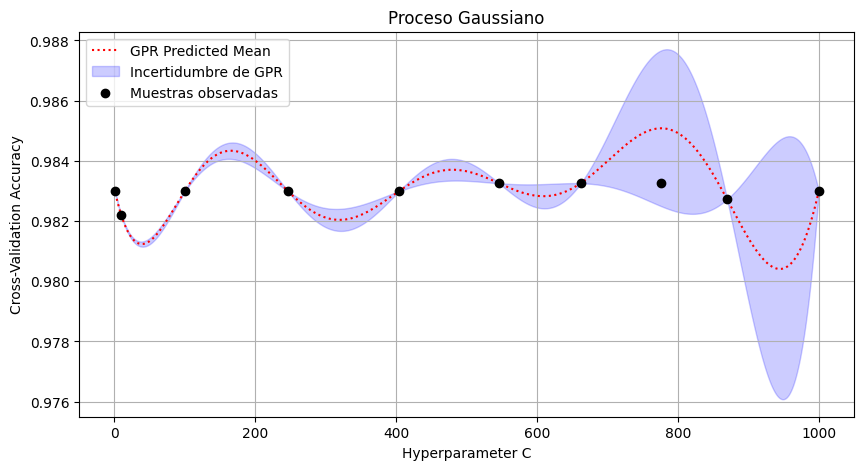

In [84]:
# Graficamos nuestra primera propuesta
plt.figure(figsize=(10, 5))
plt.plot(x_pred, y_pred, 'r:', label='GPR Predicted Mean') # Use y_pred from GPR prediction

# Dibujamos los intervalos de confianza
plt.fill_between(x_pred.ravel(),
                 y_pred - 1.96 * sigma,
                 y_pred + 1.96 * sigma,
                 alpha=0.2, color='blue', label='Incertidumbre de GPR')

plt.scatter(X_hist, y_hist, c='black', zorder=10, label='Muestras observadas') # Plot the observed points X_hist and y_hist
plt.title("Proceso Gaussiano")
plt.xlabel("Hyperparameter C")
plt.ylabel("Cross-Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

In [85]:
print(max(y_hist))
print(X_hist[np.argmax(y_hist)])


[0.98325597]
[662.06654455]
